In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# verify if dataset path is correct
!ls /content/drive/MyDrive/egg_dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  val


In [6]:
# verify the content of data yaml file
!cat /content/drive/MyDrive/egg_dataset/data.yaml

train: /content/drive/MyDrive/egg_dataset/train/images
val: /content/drive/MyDrive/egg_dataset/val/images
test: /content/drive/MyDrive/egg_dataset/test/images

nc: 1
names: ['egg']

roboflow:
  workspace: agbot
  project: agbot-2025
  version: 2
  license: MIT
  url: https://universe.roboflow.com/agbot/agbot-2025/dataset/agbot-2025


  


In [20]:
# verify the images directory exist in training set
!ls /content/drive/MyDrive/egg_dataset/train/images

frame_100_original_jpg.rf.129cf0bcd29aa24efbce9ff1742a94e8.jpg
frame_101_original_jpg.rf.688c323defed42e10f9530c14096a061.jpg
frame_102_original_jpg.rf.9648577f6a6ceb8863b6fc51d800e23f.jpg
frame_103_original_jpg.rf.a5543bc8de8d6ddffb7842dcc0382ed9.jpg
frame_105_original_jpg.rf.282f7ca2511a41aa3ac0b24fe484b779.jpg
frame_109_original_jpg.rf.ef66e439ee73234b241acbf7fbd6b611.jpg
frame_110_original_jpg.rf.07e80ed2e626ec0cb51123e8c6a40ad3.jpg
frame_111_original_jpg.rf.6882bf4441496422d5dd074ac423857b.jpg
frame_112_original_jpg.rf.9244ef3fb3f30d971d298115486281a4.jpg
frame_114_original_jpg.rf.a309fb619e28febf202d5450aec3d923.jpg
frame_115_original_jpg.rf.761ed1e00226a61922a900bf25fe7bfd.jpg
frame_116_original_jpg.rf.ae2a015bc8c567c0c5df85bf10fa2def.jpg
frame_117_original_jpg.rf.8d4b437216cfbfde891d322fc7c083a6.jpg
frame_119_original_jpg.rf.a8abc6463d51073a4133a69e8fe71a8e.jpg
frame_11_original_jpg.rf.23768c57c5e89839703a918acd5f3d71.jpg
frame_120_original_jpg.rf.dfcf4c1997cec6649c90da5b7682be

In [8]:
from ultralytics import YOLO

# Load a pretrained YOLO model
model = YOLO('yolov8n.pt')  # or 'yolov11s.pt'

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 97.0MB/s]


In [9]:
# Train the model
model.train(
    data='/content/drive/MyDrive/egg_dataset/data.yaml',
    epochs=50,
    imgsz=640,        # image size
    batch=8           # batch size (adjust for your GPU)
)

Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/egg_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

100%|██████████| 755k/755k [00:00<00:00, 19.0MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 22        [15, 18, 21]  1    751507  ultralytics.nn.modules.head.Detect           [1, [64, 128, 256]]           
Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
train: Fast image access ✅ (ping: 0.7±0.3 ms, read: 0.2±0.1 MB/s, size: 80.5 KB)


train: Scanning /content/drive/MyDrive/egg_dataset/train/labels.cache... 88 images, 1 backgrounds, 0 corrupt: 100%|██████████| 88/88 [00:00<?, ?it/s]


...

                   all         25         53      0.996          1      0.995      0.826



50 epochs completed in 1.176 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:06<00:00,  3.37s/it]


                   all         25         53      0.961          1      0.986      0.844
Speed: 2.6ms preprocess, 237.4ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab0181caa50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

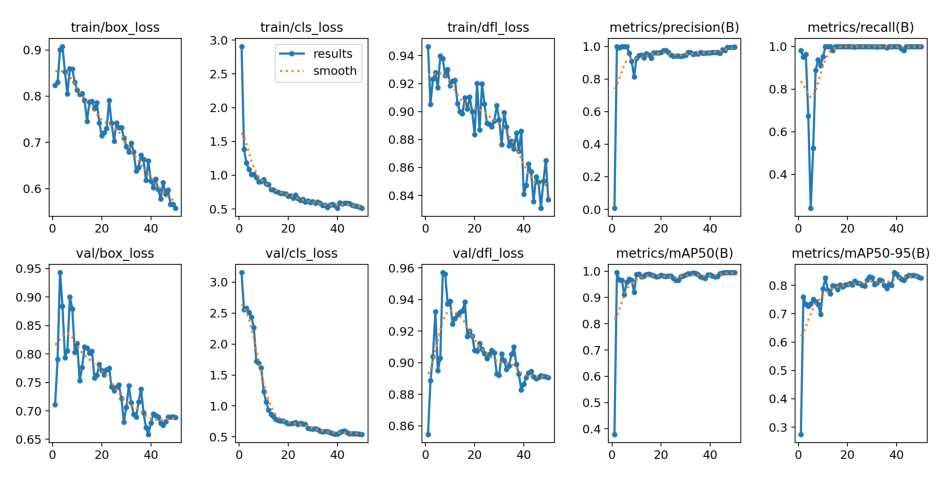

In [14]:
# see the training results
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('runs/detect/train/results.png')
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
model.val(
    data='/content/drive/MyDrive/egg_dataset/data.yaml',
    split='test'
)

Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 0.2±0.0 MB/s, size: 77.3 KB)


val: Scanning /content/drive/MyDrive/egg_dataset/test/labels... 12 images, 0 backgrounds, 0 corrupt: 100%|██████████| 12/12 [00:06<00:00,  1.74it/s]

val: New cache created: /content/drive/MyDrive/egg_dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.29s/it]


                   all         12         31      0.937      0.963      0.982      0.777
Speed: 2.0ms preprocess, 192.4ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab001951090>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
results = model.predict(source='/content/drive/MyDrive/egg_dataset/test/images', show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/12 /content/drive/MyDrive/egg_dataset/test/images/frame_107_original_jpg.rf.28a62cfb0eee1f013d702aaff05ac01d.jpg: 480x640 1 egg, 185.3ms
image 2/12 /content/drive/MyDrive/egg_dataset/test/images/frame_108_original_jpg.rf.4da066bb5bb76a6746a878edcd8d7cd8.jpg: 480x640 2 eggs, 180.5ms
image 3/12 /content/drive/MyDrive/egg_dataset/test/images/frame_113_original_jpg.rf.4084b32919c6cb91dad3eb318ccf9067.jpg: 480x640 2 eggs, 186.7ms
image 4/12 /content/drive/MyDrive/egg_dataset/test/images/frame_121_original_jpg.rf.8f71a4179bed8561f77a425e999b4098.jpg: 480x640 3 eggs, 172.3ms
image 5/12 /content/drive/MyDrive/egg_dataset/test/images/frame_16_original_jpg.rf.5e0657f08459d279c6fdbef5a001f7e7.jpg: 480x640 3 eggs, 179.9ms
image 6/12 /content/drive/MyDrive/egg_dataset/test/images/frame_30_original_jpg.rf.d8a1bdd5bdaf15445d668adff4fe3578.jpg: 480x640 2 eggs, 171.2ms
image 7/12 /content/drive/MyDrive/egg_dataset/test/i

In [12]:
from ultralytics import YOLO

# Load the TensorRT model
model = YOLO("runs/detect/train/weights/best.pt")
model.export(format="onnx")

Ultralytics 8.3.137 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel CPUs. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<1.18.0', 'onnxslim>=0.1.53', 'onnxruntime'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 199.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 200.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 162.1 MB/s eta 0:00:00

requirements: AutoUpdate

'runs/detect/train/weights/best.onnx'

In [13]:
# download the model
from google.colab import files
files.download('runs/detect/train/weights/best.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>